# Start

In this *notebook* I worked on getting to know, cleaning and reshaping the
data, to bring it closer to what this *EDA* sets out to analyse.

Fun fact: in analysis projects it is estimated that 80% of the time goes into
transforming and cleaning the dataset, and the remaining 20% into drawing out
the *insights*, plotting and the final visual adjustments.

Even though this is a dataset published by the Washington State government,
there are inconsistencies — often data for which no official information
exists — and columns of little interest to our *EDA*, which focuses on things
such as range, *market share* and the evolution of the technology. Details
like the chassis number, the survey id, the postal code and others that do not
fit the idea of the project were therefore removed.

<table align="left">
  <tr>
    <td>
      <a href="https://colab.research.google.com/github/ValentimPiazera/EDA-Carros-Eletricos-Washington/blob/main/notebooks/I-cleaning.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
      </a>
    </td>
    <td>
      <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ValentimPiazera/EDA-Carros-Eletricos-Washington/blob/main/notebooks/I-cleaning.ipynb">
        <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
      </a>
    </td>
  </tr>
</table>

> **Note:** this notebook is written to run from the **repository root**, not from `notebooks/`.
> Locally, `.vscode/settings.json` already points VS Code's Jupyter root at the workspace folder;
> from a terminal, launch Jupyter from the repository root.
>
> If you're running on Google Colab or Kaggle, run the cell below first: it clones the repository
> so that the `src/` module and data files are available.
>
> On **Kaggle**, make sure Internet access is enabled: *Settings → Internet → On*.

In [1]:
# Setup: clone repo when running on Colab/Kaggle (skip if running locally!)
import os

REPO = "EDA-Carros-Eletricos-Washington"

IN_COLAB_OR_KAGGLE = (
    "google.colab" in str(get_ipython())
    or "kaggle" in os.environ.get("KAGGLE_URL_BASE", "").lower()
)

# The second test is what makes the cell re-runnable: once the working
# directory is the repository root there is nothing left to clone or enter.
if IN_COLAB_OR_KAGGLE and os.path.basename(os.getcwd()) != REPO:
    if not os.path.exists(REPO):
        !git clone https://github.com/ValentimPiazera/{REPO}.git
    # The repo root becomes the working directory, so the `data/` paths
    # and `from src import cleaning` resolve as they do locally.
    %cd {REPO}


## Part I — Imports and Loading

Importing the libraries and reading the raw CSV exported by the *DOL*.

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from src import cleaning, utils

In [3]:
df = pd.read_csv("data/raw/Electric_Vehicle_Population_Data_20260122.csv")

df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10


## Part II — Initial Inspection

Basic reconnaissance of the *dataframe*: its shape, the type of each column,
the distribution of the numeric variables and whether there are null values.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271113 entries, 0 to 271112
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         271113 non-null  str    
 1   County                                             271103 non-null  str    
 2   City                                               271103 non-null  str    
 3   State                                              271113 non-null  str    
 4   Postal Code                                        271103 non-null  float64
 5   Model Year                                         271113 non-null  int64  
 6   Make                                               271113 non-null  str    
 7   Model                                              271113 non-null  str    
 8   Electric Vehicle Type                              271113 non-null  str    
 9   Clea

In [5]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,271103.000000,271113.000000,271106.000000,270454.000000,2.711130e+05,2.711030e+05
mean,98176.923405,2021.995068,39.885639,28.813229,2.449143e+08,5.297202e+10
std,2576.510222,3.056730,78.764355,14.898449,6.365566e+07,1.632879e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.201288e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.619548e+08,5.303303e+10
75%,98382.000000,2024.000000,33.000000,42.000000,2.781037e+08,5.305394e+10
max,99577.000000,2026.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


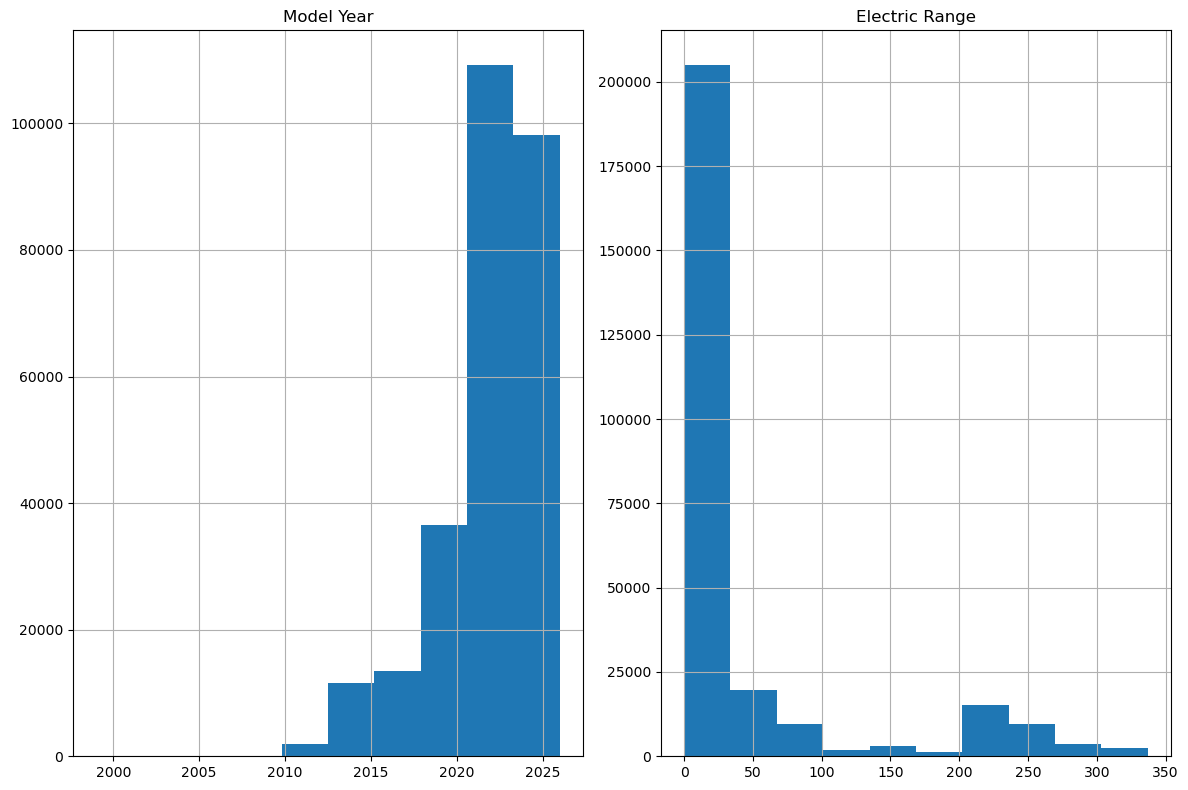

In [6]:
df[["Model Year", "Electric Range"]].hist(figsize=(12, 8))

plt.tight_layout()
plt.show()

In [7]:
df.isna().sum()

VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         7
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      88
Electric Utility                                      10
2020 Census Tract                                     10
dtype: int64

## Part III — Row Removal

* **1 —** I removed 10 rows holding *NaNs*; they were registration details:
city, county and postal code. Although they are not essential to the analysis
ahead, I decided to drop them, because 10 rows out of a *Dataframe* of roughly
271 thousand is no great loss.

* **2 —** I removed every row that did not refer to Washington State, since
the state is the focus of the research. That is 649 records, again not much
against the 270 thousand rows that remain.

In [8]:
df = cleaning.drop_incomplete_rows(df)
df.isna().sum()

VIN (1-10)                                             0
County                                                 0
City                                                   0
State                                                  0
Postal Code                                            0
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         7
Legislative District                                 649
DOL Vehicle ID                                         0
Vehicle Location                                      78
Electric Utility                                       0
2020 Census Tract                                      0
dtype: int64

In [9]:
df = cleaning.keep_washington(df)
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271108,5YJ3E1EC8P,Snohomish,Woodinville,WA,98077.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,241530824,POINT (-122.07326 47.75425),PUGET SOUND ENERGY INC,5.306105e+10
271109,7FCEHEB2XR,Skagit,Burlington,WA,98233.0,2024,RIVIAN,EDV,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,10.0,283223496,POINT (-122.33029 48.46846),PUGET SOUND ENERGY INC,5.305795e+10
271110,3GPKHZRJ8R,Clark,Vancouver,WA,98682.0,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,17.0,276399231,POINT (-122.55149 45.69345),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
271111,1C4JJXN6XP,Pierce,Tacoma,WA,98406.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,28.0,280031559,POINT (-122.52082 47.26887),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10


## Part IV — Unusable Range

Looking at the range values in *Data Wrangler*, a great many cars sit at 0.
Digging further, I found that they are the more recent vehicles, whose range
has not been officially recorded yet. Columns such as the legislative district
and the coordinates also hold null or zeroed values, but I will leave those as
*NaN*, since those columns matter little to the analysis.

The zeros are not the only figure in that column that is not a measurement, so
the rule I apply is a single one: **a range outside what the row's own vehicle
type can reach says nothing true about that vehicle**, and becomes *NaN*. On
this export it catches three groups:

* the DOL's **0**, for a battery it has not researched;
* **1 mile**, on 32 model year 2025 Mercedes-Benz plug-ins, in a file that
holds nothing whatsoever between 2 and 5;
* **29 miles**, on 8 rows badged BEV — which is the published figure for the
*plug-in* Hyundai IONIQ, so the row's type and its range contradict each other.

Genuinely low figures survive: the 6 miles of the 2012–2015 Prius Plug-in and
of the Lamborghini Revuelto, and the 8 and 9 of the Mercedes C350e, are real
EPA ratings sitting comfortably above their type's floor.

In [10]:
df = cleaning.blank_unusable_range(df)
df["Electric Range"].isna().sum()

np.int64(170477)

## Part V — Columns: Removal, Recoding and Derivation

I will remove the vehicle location, legislative district, vin (the chassis
identifier), postal code, 2020 census tract, state (given that they are all
Washington) and *DOL* (Washington's equivalent of a vehicle licensing agency)
columns, since this EDA is about the market rather than precise geographic
statistics.

Then come the recodings: shorter and more intuitive column and cell names,
*NaNs* for the cars whose clean fuel alternative has not been researched, a
standardisation of the electric utility names — where
`No Known Electric Utility Service` becomes *NaN*, because it records the
absence of a provider rather than a provider — and the collapsing of the three
cities the source spells two ways. Last, I create the vehicle age column,
measured in years against the year of the *snapshot* (2026).

In [11]:
df = cleaning.drop_unused_columns(df)
df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)


In [12]:
df = cleaning.shorten_cafv_status(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),NaN,NaN,PUGET SOUND ENERGY INC
271109,Skagit,Burlington,2024,RIVIAN,EDV,Battery Electric Vehicle (BEV),NaN,NaN,PUGET SOUND ENERGY INC
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...


In [13]:
df = cleaning.abbreviate_vehicle_type(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,PUGET SOUND ENERGY INC
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,PUGET SOUND ENERGY INC
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...


In [14]:
df.columns

Index(['County', 'City', 'Model Year', 'Make', 'Model',
       'Electric Vehicle Type', 'CAFV Status', 'Electric Range',
       'Electric Utility'],
      dtype='str')

In [15]:
df = cleaning.add_vehicle_age(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,PUGET SOUND ENERGY INC,8
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),15
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,PACIFICORP,6
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),6
...,...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,PUGET SOUND ENERGY INC,3
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,PUGET SOUND ENERGY INC,2
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,2
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,3


In [16]:
df["Electric Utility"].unique()

<StringArray>
[                                                                                          'PUGET SOUND ENERGY INC',
                                                                    'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
                                                                                                       'PACIFICORP',
                                                                     'CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)',
                                                                                                      'AVISTA CORP',
                                                                                        'PUD NO 1 OF CHELAN COUNTY',
                                                                                         'PUD NO 2 OF GRANT COUNTY',
                                                                                    'MODERN ELECTRIC WATER COMPANY',
                                                  

In [17]:
df = cleaning.simplify_utility(df)
df["Electric Utility"].unique()

<StringArray>
[             'Puget Sound Energy',                      'Pacificorp',
                 'City Of Seattle',                     'Avista Corp',
       'Pud No 1 Of Chelan County',        'Pud No 2 Of Grant County',
   'Modern Electric Water Company',      'Pud No 1 Of Douglas County',
                               nan, 'Pud No 1 Of Pend Oreille County',
 'Bonneville Power Administration',                  'City Of Tacoma',
    'Portland General Electric Co',                'City Of Chewelah',
                  'City Of Blaine',                  'City Of Cheney',
     'Pud No 1 Of Okanogan County',       'Okanogan County Elec Coop',
      'Pud No 1 Of Whatcom County',                   'City Of Sumas']
Length: 20, dtype: str

In [18]:
df = cleaning.standardise_city(df)
df["City"].nunique()

491

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 270454 entries, 0 to 271112
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   County                 270454 non-null  str    
 1   City                   270454 non-null  str    
 2   Model Year             270454 non-null  int64  
 3   Make                   270454 non-null  str    
 4   Model                  270454 non-null  str    
 5   Electric Vehicle Type  270454 non-null  str    
 6   CAFV Status            99977 non-null   str    
 7   Electric Range         99977 non-null   float64
 8   Electric Utility       270104 non-null  str    
 9   Vehicle Age            270454 non-null  int64  
dtypes: float64(1), int64(2), str(7)
memory usage: 22.7 MB


## Part VI — Outliers and Plausibility

To check for *outliers* I decided to identify them through the quartile
method, which means finding the lowest values (the bottom 25%) and the highest
(the top 75%) and comparing them against the spread they define.

The quartile method answers only one question, though: which values sit far
from the rest of this column? It cannot say whether a value is *possible*. On
a column as bimodal as this one — BEVs around 215 miles against PHEVs around
32 — the fence is wide enough to swallow a plug-in claiming a single mile. So
the last check below is a different one: bounds taken from the domain rather
than from the distribution.

In [20]:
utils.outliers_quartile(df, "Vehicle Age")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
6,King,Seattle,2016,AUDI,A3,PHEV,Not Eligible (Low Range),16.0,City Of Seattle,10
12,Thurston,Olympia,2013,NISSAN,LEAF,BEV,Eligible,75.0,Puget Sound Energy,13
14,Yakima,Yakima,2016,TESLA,MODEL X,BEV,Eligible,200.0,Pacificorp,10
...,...,...,...,...,...,...,...,...,...,...
271017,Clallam,Port Angeles,2013,TESLA,MODEL S,BEV,Eligible,208.0,Bonneville Power Administration,13
271056,Snohomish,Arlington,2015,NISSAN,LEAF,BEV,Eligible,84.0,Bonneville Power Administration,11
271059,Snohomish,Snohomish,2015,FIAT,500,BEV,Eligible,87.0,Puget Sound Energy,11
271071,Whatcom,Bellingham,2015,TESLA,MODEL S,BEV,Eligible,208.0,Puget Sound Energy,11


In [21]:
# The whole-fleet run comes back empty because of how many NaNs there are,
# so I check it another way below

utils.outliers_quartile(df, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age


In [22]:
print(df["Electric Range"].quantile(0.25))
print(df["Electric Range"].quantile(0.75))
print(df["Electric Range"].max())

30.0
215.0
337.0


In [23]:
bevs = df[df["Electric Vehicle Type"] == "BEV"]

print(bevs["Electric Range"].quantile(0.25))
print(bevs["Electric Range"].quantile(0.75))
print(bevs["Electric Range"].max())

150.0
238.0
337.0


In [24]:
utils.outliers_quartile(bevs, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age


In [25]:
phevs = df[df["Electric Vehicle Type"] == "PHEV"]

print(phevs["Electric Range"].quantile(0.25))
print(phevs["Electric Range"].quantile(0.75))
print(phevs["Electric Range"].max())

21.0
38.0
153.0


In [26]:
utils.outliers_quartile(phevs, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
30,Thurston,Olympia,2018,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,8
94,King,Renton,2014,BMW,I3,PHEV,Eligible,72.0,Puget Sound Energy,12
206,King,Seattle,2019,BMW,I3,PHEV,Eligible,126.0,City Of Seattle,7
220,Snohomish,Edmonds,2017,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,9
295,Kitsap,Port Orchard,2017,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,9
...,...,...,...,...,...,...,...,...,...,...
268849,Thurston,Olympia,2020,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,6
269887,Island,Coupeville,2014,BMW,I3,PHEV,Eligible,72.0,Puget Sound Energy,12
270523,Whatcom,Bellingham,2019,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,7
271075,King,Woodinville,2019,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,7


In [27]:
utils.outliers_quartile(df, "Model Year")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
6,King,Seattle,2016,AUDI,A3,PHEV,Not Eligible (Low Range),16.0,City Of Seattle,10
12,Thurston,Olympia,2013,NISSAN,LEAF,BEV,Eligible,75.0,Puget Sound Energy,13
14,Yakima,Yakima,2016,TESLA,MODEL X,BEV,Eligible,200.0,Pacificorp,10
...,...,...,...,...,...,...,...,...,...,...
271017,Clallam,Port Angeles,2013,TESLA,MODEL S,BEV,Eligible,208.0,Bonneville Power Administration,13
271056,Snohomish,Arlington,2015,NISSAN,LEAF,BEV,Eligible,84.0,Bonneville Power Administration,11
271059,Snohomish,Snohomish,2015,FIAT,500,BEV,Eligible,87.0,Puget Sound Energy,11
271071,Whatcom,Bellingham,2015,TESLA,MODEL S,BEV,Eligible,208.0,Puget Sound Energy,11


In [28]:
utils.implausible_range(df)

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age,Plausibility


**Conclusion:** none of the values flagged by the quartile method was
removed. The 1999 Ford Ranger and the models whose range sits far above the
median are genuine records, and the distance between them is the technological
gap of a *dataset* spanning 27 years — there is no false figure here, of the
kind a car with 50,000 km of range would be. Run over the whole fleet, the
test on the range column returns an empty *dataframe* because of the 63% of
*NaNs*; split between BEVs and PHEVs, neither shows *outliers*. And the model
year is information tied to the vehicle age, so it adds nothing of its own.

The plausibility check is what found what the quartiles could not: the 8 rows
badged **BEV** carrying 29 miles, all of them 2019 Hyundai IONIQs, against the
published figure for the IONIQ *Plug-in Hybrid*. Type and range contradict
each other there, and rather than average a plug-in's rating into every BEV
statistic downstream, Part IV blanks the range and keeps the row. Which is why
the cell above comes back empty: it is the proof that nothing in the exported
file claims a range its own type could not reach — and the alarm that would
sound first if the snapshot were ever refreshed, including for a vehicle type
this project has never seen, which it reports rather than skips.

## Part VII — Sanity Check and Export

The culmination of the cleaning, perhaps the simplest part of this *notebook*
but the most rewarding; here I run the checks and the final adjustments before
exporting the file to CSV.

`cleaning.check_export` is a check rather than a display: it raises if the
frame breaks any of the promises the cleaning makes about it — a range
impossible for its own vehicle type, a CAFV ruling left behind by the range it
was read off, a vehicle age that disagrees with its model year, a city arriving
under two spellings, or an empty value in a field that should never be empty.
Each of those lines is a defect this project shipped at some point.

In [29]:
df.describe()

,Model Year,Electric Range,Vehicle Age
count,270454.000000,99977.000000,270454.000000
mean,2021.995929,107.881213,4.004071
std,3.057503,97.171729,3.057503
min,1999.000000,6.000000,0.000000
25%,2021.000000,30.000000,2.000000
50%,2023.000000,48.000000,3.000000
75%,2024.000000,215.000000,5.000000
max,2026.000000,337.000000,27.000000


In [30]:
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,Puget Sound Energy,8
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,Pacificorp,6
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,City Of Seattle,6
...,...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,Puget Sound Energy,3
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,Puget Sound Energy,2
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,Bonneville Power Administration,2
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,Bonneville Power Administration,3


In [31]:
cleaning.check_export(df)

rows                                    270454
columns                                     10
ranges outside their type's bounds           0
statuses left without a range                0
ages disagreeing with the model year         0
cities spelled more than one way             0
required fields left empty                   0
dtype: int64

In [32]:
df.to_csv("data/processed/ev_population_washington_clean.csv", index=False)

## Q&A

**Q: There are clearly *outliers*! Why did you do nothing about them?**

Fair enough — by brute mathematics, a case such as a 1999 Ford being electric
can be counted as an *outlier*, but it is neither false nor incorrect, just
something common in a *Dataframe* as varied as this one, which holds hybrids
and full electrics and models more than 20 years apart.

**Q: Why remove so many columns?**

My analysis is about *market share*, the evolution of the technology and basic
geography, so columns such as the chassis number do not matter; and columns
such as the coordinates do not suit the intent of the research, however rich
they would be for other kinds of analysis.

**Q: Why remove the 10 rows?**

Since it is only 10 rows holding NaN against 270 thousand, dropping them makes
no difference; besides, the information is very specific and hard to track
down, so reconstructing those rows is not worth it.